In [1]:
import numpy as np
import pandas as pd
import missingno
pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [2]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 - Level/Greece/data/'

In [3]:
NUTS2 = 'Peloponnese'
YEAR = '2009-2023'

In [4]:
data = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [5]:
try:
    data.drop(columns=['Unnamed: 0'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

In [6]:
try:
    data.drop(columns=['Unnamed: 0.1'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

<Axes: >

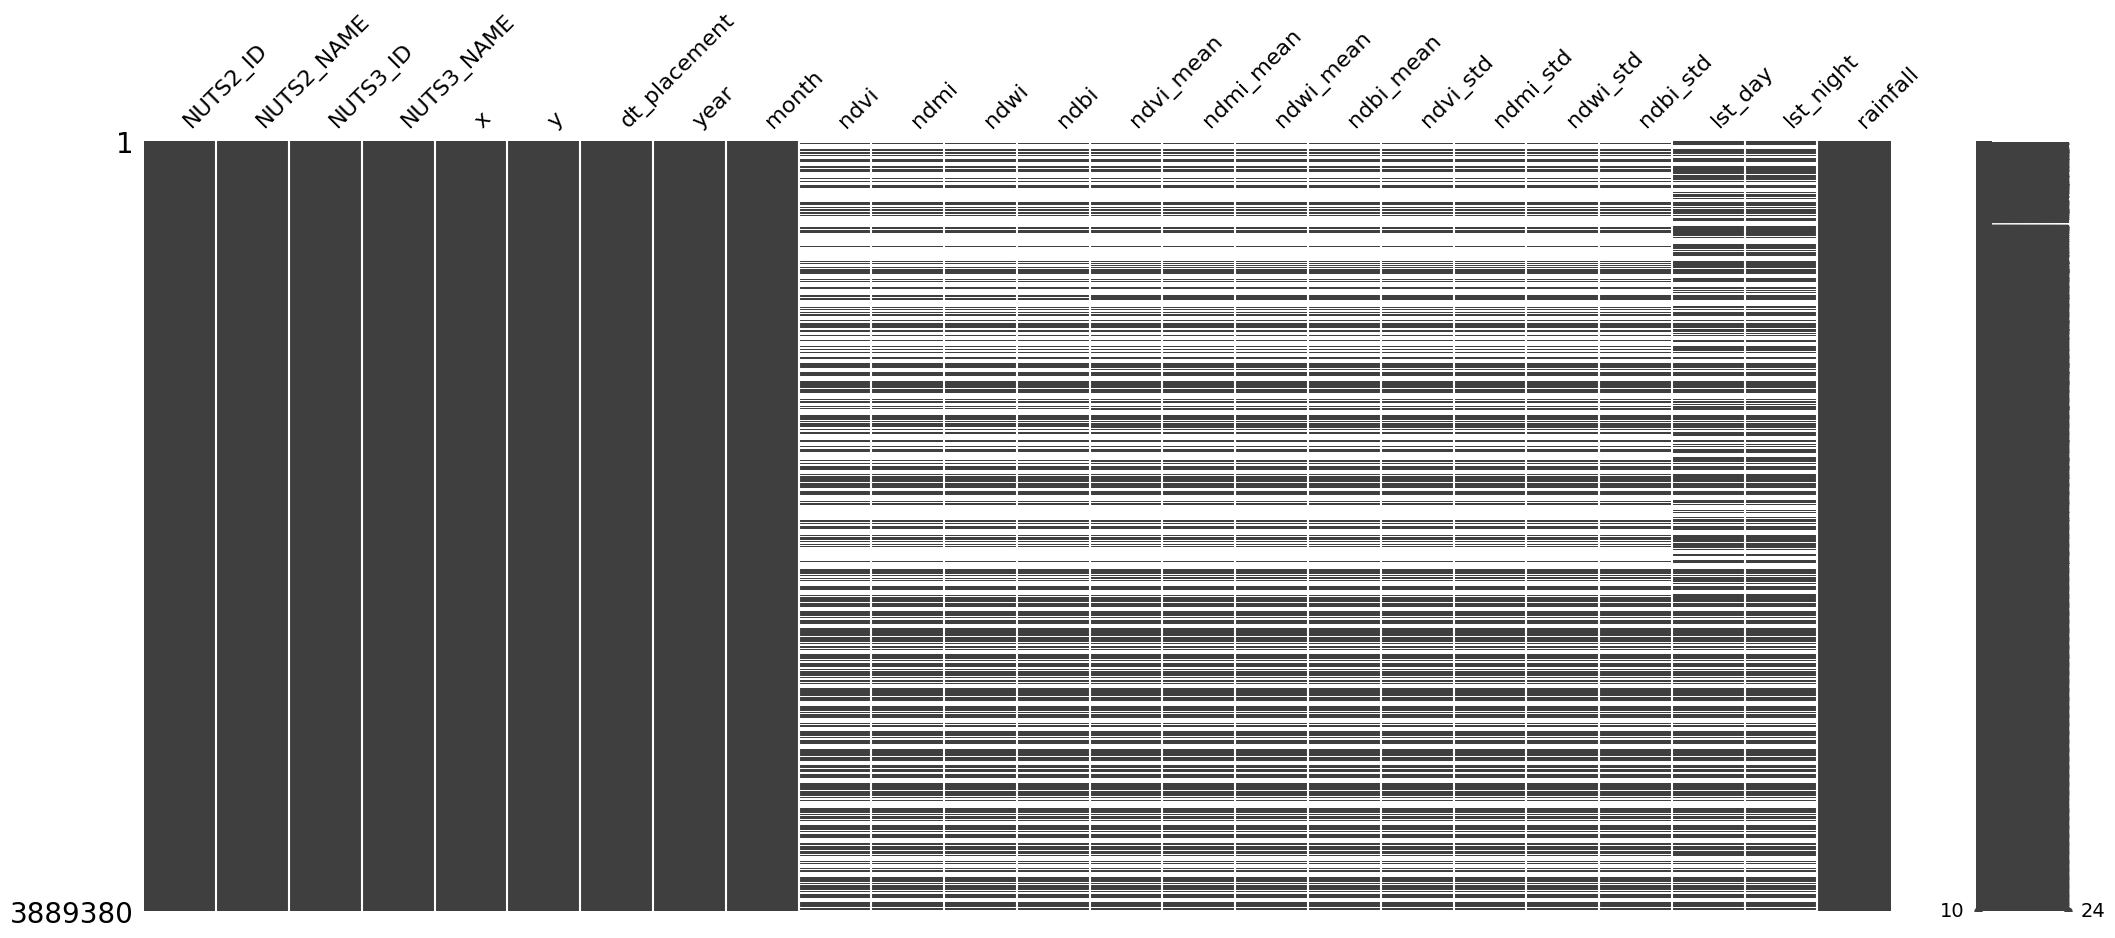

In [7]:
missingno.matrix(data)

In [8]:
data.dtypes

NUTS2_ID         object
NUTS2_NAME       object
NUTS3_ID         object
NUTS3_NAME       object
x               float64
y               float64
dt_placement     object
year              int64
month             int64
ndvi            float64
ndmi            float64
ndwi            float64
ndbi            float64
ndvi_mean       float64
ndmi_mean       float64
ndwi_mean       float64
ndbi_mean       float64
ndvi_std        float64
ndmi_std        float64
ndwi_std        float64
ndbi_std        float64
lst_day         float64
lst_night       float64
rainfall        float64
dtype: object

In [9]:
# data.lst_day.unique()

In [10]:
# data['lst_day'] = data['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [11]:
# data['lst_day'] = data['lst_day'].astype(float)

In [12]:
# data.drop(columns=['rainfall.1'], inplace=True)

In [13]:
data['dt_placement'] = pd.to_datetime(data['dt_placement'])

# Extract year, month, and day from the 'date' column
data['year'] = data['dt_placement'].dt.year
data['month'] = data['dt_placement'].dt.month
data['day'] = data['dt_placement'].dt.day

In [14]:
data

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day
0,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.85941,37.62453,2009-01-01,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.0,NaN,0.115554,1
1,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.85941,37.62453,2009-01-02,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.0,NaN,29.973920,2
2,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.85941,37.62453,2009-01-03,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.0,NaN,49.195785,3
3,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.85941,37.62453,2009-01-04,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.0,NaN,7.258097,4
4,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.85941,37.62453,2009-01-05,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.0,NaN,49.884600,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3889375,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",23.03455,36.80511,2023-12-27,2023,12,0.498198,0.340645,-0.295511,-0.340645,0.544060,0.278207,-0.390765,-0.278207,0.045534,0.064306,0.081898,0.064306,14372.0,14132.0,0.000000,27
3889376,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",23.03455,36.80511,2023-12-28,2023,12,0.498198,0.340645,-0.295511,-0.340645,0.544060,0.278207,-0.390765,-0.278207,0.045534,0.064306,0.081898,0.064306,14339.0,14091.0,0.000000,28
3889377,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",23.03455,36.80511,2023-12-29,2023,12,0.477178,0.338346,-0.272944,-0.338346,0.525961,0.280349,-0.367922,-0.280349,0.047410,0.063162,0.083673,0.063162,14340.0,14091.0,0.000000,29
3889378,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",23.03455,36.80511,2023-12-30,2023,12,0.477178,0.338346,-0.272944,-0.338346,0.525961,0.280349,-0.367922,-0.280349,0.047410,0.063162,0.083673,0.063162,14340.0,14091.0,0.000000,30


In [15]:
data_jan = data.loc[data['month'] == 1]
data_fed = data.loc[data['month'] == 2]
data_mar = data.loc[data['month'] == 3]
data_apr = data.loc[data['month'] == 4]

In [17]:
df_mean_jan = data_jan.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_feb = data_fed.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_mar = data_mar.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_apr = data_apr.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()

KeyError: 'cell_number'

In [ ]:
df_mean_jan.rename(columns={'lst_day': 'lst_day_jan_mean', 'lst_night': 'lst_night_jan_mean'}, inplace=True)
df_mean_feb.rename(columns={'lst_day': 'lst_day_feb_mean', 'lst_night': 'lst_night_feb_mean'}, inplace=True)
df_mean_mar.rename(columns={'lst_day': 'lst_day_mar_mean', 'lst_night': 'lst_night_mar_mean'}, inplace=True)
df_mean_apr.rename(columns={'lst_day': 'lst_day_apr_mean', 'lst_night': 'lst_night_apr_mean'}, inplace=True)

In [18]:
df_mean_jan.drop(columns=['month'], inplace = True)
df_mean_feb.drop(columns=['month'], inplace = True)
df_mean_mar.drop(columns=['month'], inplace = True)
df_mean_apr.drop(columns=['month'], inplace = True)

NameError: name 'df_mean_jan' is not defined

In [311]:
df_mean = pd.merge(df_mean_jan, df_mean_feb, on=['cell_number', 'year']).merge(df_mean_mar, on=['cell_number', 'year']).merge(df_mean_apr, on=['cell_number', 'year'])

In [312]:
df_mean.loc[(df_mean['cell_number'] == 0) & (df_mean['year'] == YEAR)]

,cell_number,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean


In [313]:
data_mean = pd.merge(data, df_mean, on=['cell_number', 'year'])

In [314]:
data_mean

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,22.92536,36.22923,0,2023-01-01,EL30,2023,1,0.484009,0.144737,-0.416691,-0.144737,0.439198,0.167151,-0.350327,-0.167151,0.067629,0.035950,0.075527,0.035950,14400.0,14170.0,0.051035,1,14333.129032,14079.419355,14288.750000,14009.107143,14514.677419,14048.741935,14636.200000,14207.466667
1,22.92536,36.22923,0,2023-01-02,EL30,2023,1,0.484009,0.144737,-0.416691,-0.144737,0.439198,0.167151,-0.350327,-0.167151,0.067629,0.035950,0.075527,0.035950,14414.0,14084.0,0.000000,2,14333.129032,14079.419355,14288.750000,14009.107143,14514.677419,14048.741935,14636.200000,14207.466667
2,22.92536,36.22923,0,2023-01-03,EL30,2023,1,0.484009,0.144737,-0.416691,-0.144737,0.439198,0.167151,-0.350327,-0.167151,0.067629,0.035950,0.075527,0.035950,14358.0,14093.0,0.000000,3,14333.129032,14079.419355,14288.750000,14009.107143,14514.677419,14048.741935,14636.200000,14207.466667
3,22.92536,36.22923,0,2023-01-04,EL30,2023,1,0.484009,0.144737,-0.416691,-0.144737,0.439198,0.167151,-0.350327,-0.167151,0.067629,0.035950,0.075527,0.035950,14404.0,14101.0,0.000000,4,14333.129032,14079.419355,14288.750000,14009.107143,14514.677419,14048.741935,14636.200000,14207.466667
4,22.92536,36.22923,0,2023-01-05,EL30,2023,1,0.488903,0.133752,-0.417446,-0.133752,0.453060,0.149056,-0.369614,-0.149056,0.051385,0.044724,0.064931,0.044724,14382.0,14134.0,0.000000,5,14333.129032,14079.419355,14288.750000,14009.107143,14514.677419,14048.741935,14636.200000,14207.466667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269000,24.05547,37.79233,736,2023-12-27,EL30,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,14444.0,14179.0,0.000000,27,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000
269001,24.05547,37.79233,736,2023-12-28,EL30,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,14454.0,14178.0,0.000000,28,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000
269002,24.05547,37.79233,736,2023-12-29,EL30,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,14416.0,14178.0,0.000000,29,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000
269003,24.05547,37.79233,736,2023-12-30,EL30,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,14416.0,14178.0,0.000000,30,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000


<Axes: >

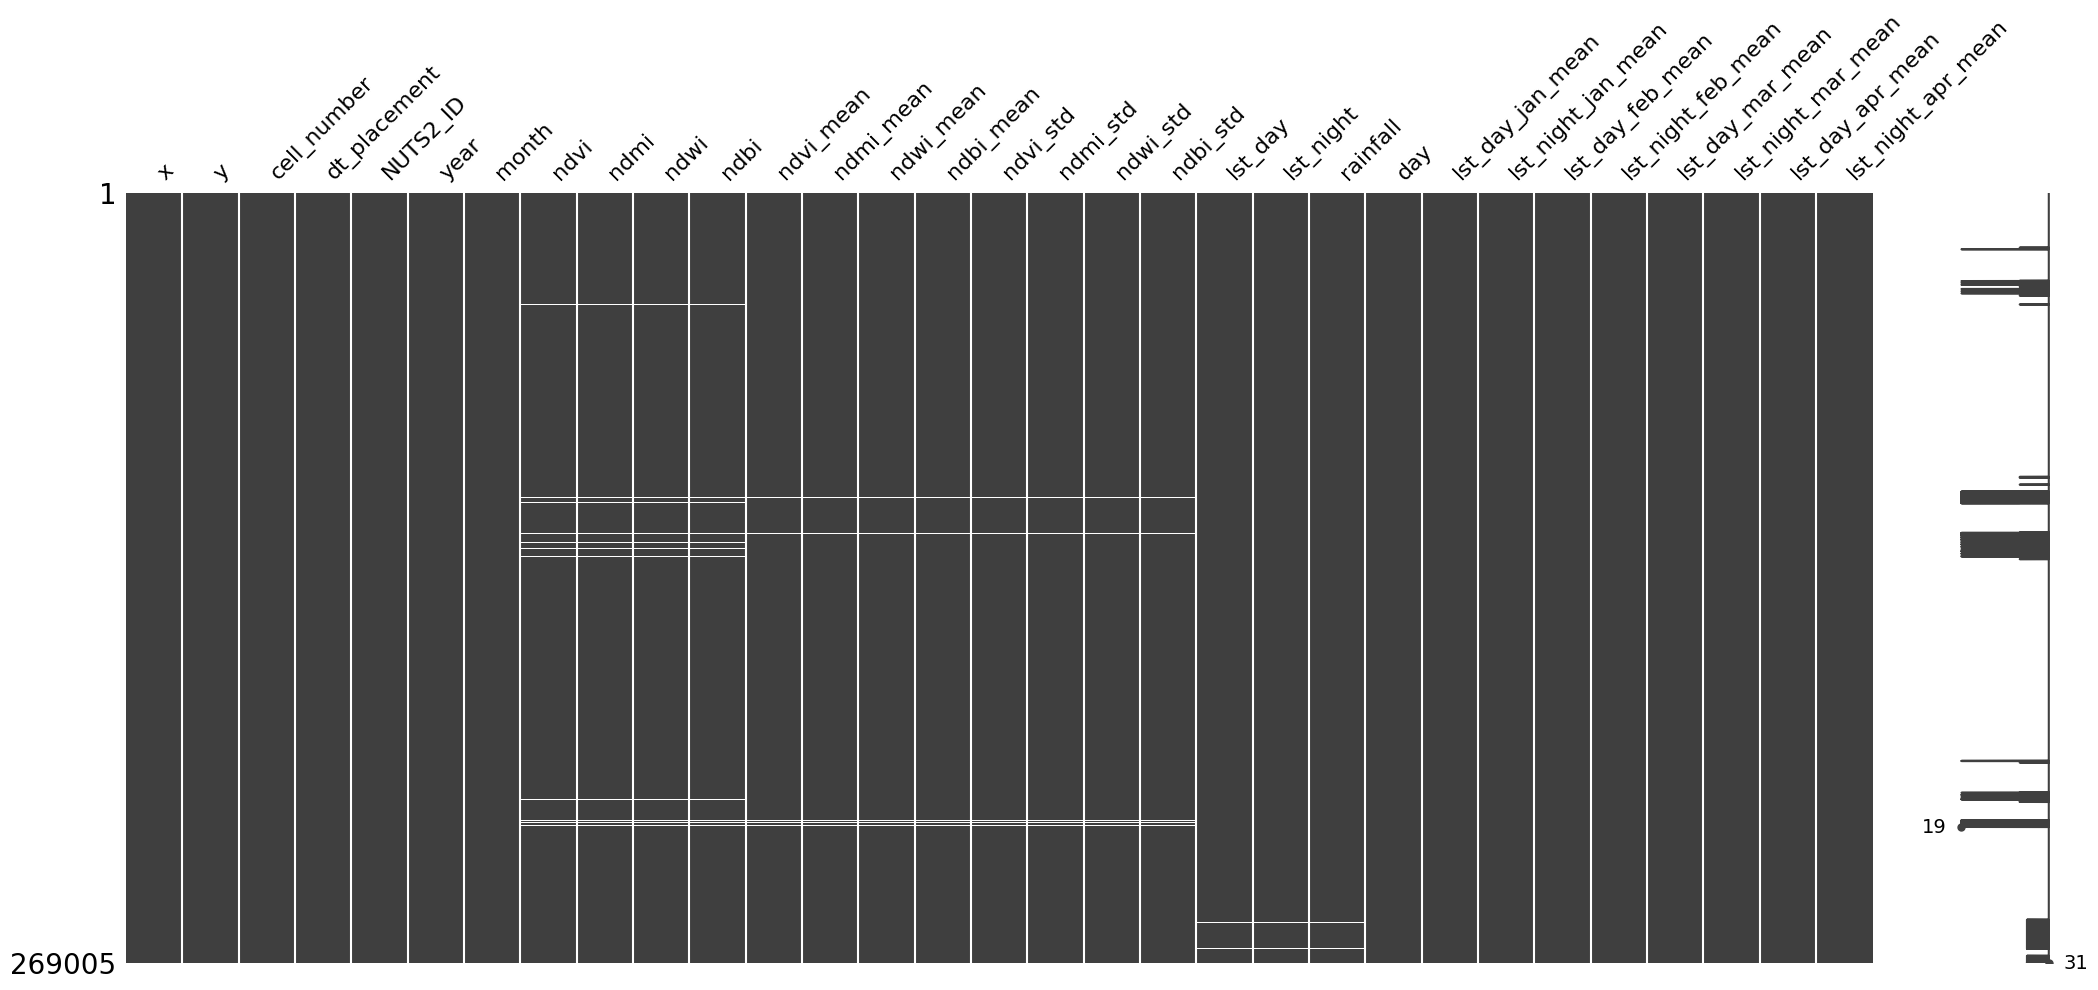

In [315]:
missingno.matrix(data_mean)

In [316]:
data_mean.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled_mean.csv', encoding='utf-8')